# 01 — Exploratory Data Analysis

**Dataset:** Corporación Favorita Grocery Sales (Kaggle)
**Scope:** 18 Quito stores, 2015-01-02 to 2016-12-31, 581 SKU-store pairs, 33 product families

This notebook explores the cleaned `daily_demand` table before any classification or
inventory modeling is applied. Goal: understand demand scale, spread, and time patterns
so that the ABC-XYZ classification (notebook 02) and safety stock model make sense in
context.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

PROJECT_ROOT = Path.cwd().parent
DB_PATH = PROJECT_ROOT / "data" / "inventory.db"
CLEANED = PROJECT_ROOT / "data" / "cleaned"

conn = sqlite3.connect(DB_PATH)
print(f"Connected to {DB_PATH}")

Connected to D:\CS (2)\PES\Projects\inventory-optimization\data\inventory.db


## Store scope

In [2]:
stores = pd.read_csv(CLEANED / "stores_scoped.csv")
print(f"{len(stores)} stores in scope, all in Quito")
stores.groupby(["type", "cluster"]).size().rename("num_stores").reset_index()

54 stores in scope, all in Quito


,type,cluster,num_stores
0,A,5,1
1,A,11,3
2,A,14,4
3,A,17,1
4,B,6,6
5,B,10,1
6,B,16,1
7,C,3,7
8,C,7,2
9,C,12,1


## Product family overview

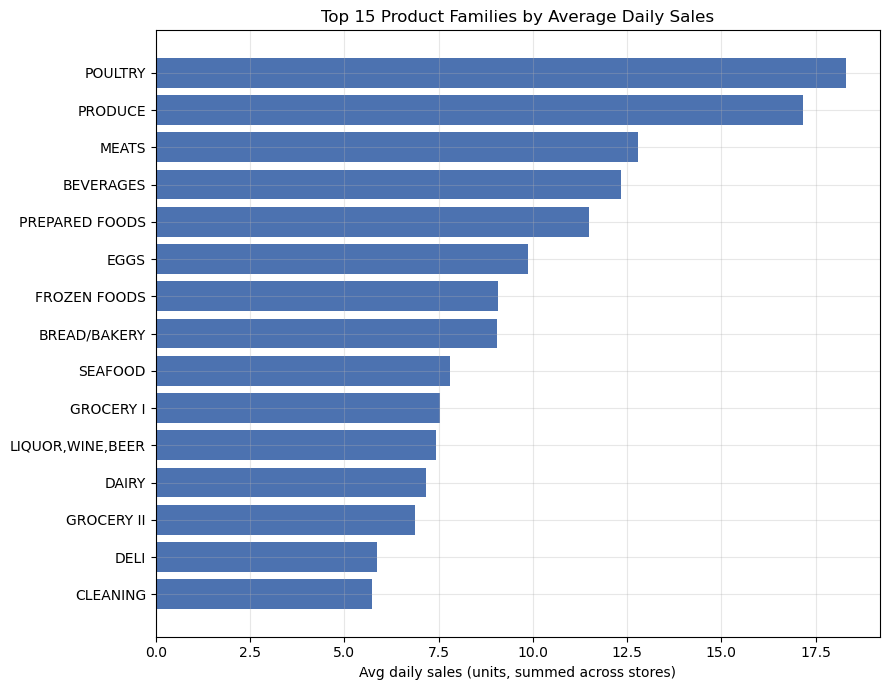

,family,num_stores,total_obs,total_units,avg_daily_sales
6,POULTRY,54,1742403,"31,876,004.00",18.29
2,PRODUCE,54,7154303,"122,704,679.00",17.15
7,MEATS,54,2432048,"31,086,468.00",12.78
1,BEVERAGES,54,17567388,"216,942,246.00",12.35
13,PREPARED FOODS,54,766588,"8,799,871.00",11.48
11,EGGS,54,1580833,"15,588,296.00",9.86
12,FROZEN FOODS,54,1549398,"14,071,786.00",9.08
5,BREAD/BAKERY,54,4659246,"42,133,946.00",9.04
15,SEAFOOD,54,257895,"2,015,396.00",7.81
0,GROCERY I,54,45628065,"343,461,728.00",7.53


In [3]:
family_overview = pd.read_csv(CLEANED / "family_overview.csv").sort_values(
    "avg_daily_sales", ascending=False
)

fig, ax = plt.subplots(figsize=(9, 7))
top = family_overview.head(15).iloc[::-1]
ax.barh(top["family"], top["avg_daily_sales"], color="#4C72B0")
ax.set_xlabel("Avg daily sales (units, summed across stores)")
ax.set_title("Top 15 Product Families by Average Daily Sales")
plt.tight_layout()
plt.show()

family_overview.head(10)

## Demand distribution across SKU-store pairs

Each row of `demand_summary` is one (store, item) pair. The distribution is heavily
right-skewed — a small number of SKUs sell in the thousands of units/day (mostly
GROCERY I staples) while the long tail sells in single digits. This skew is exactly
what the ABC classification (revenue concentration) will formalize in notebook 02.

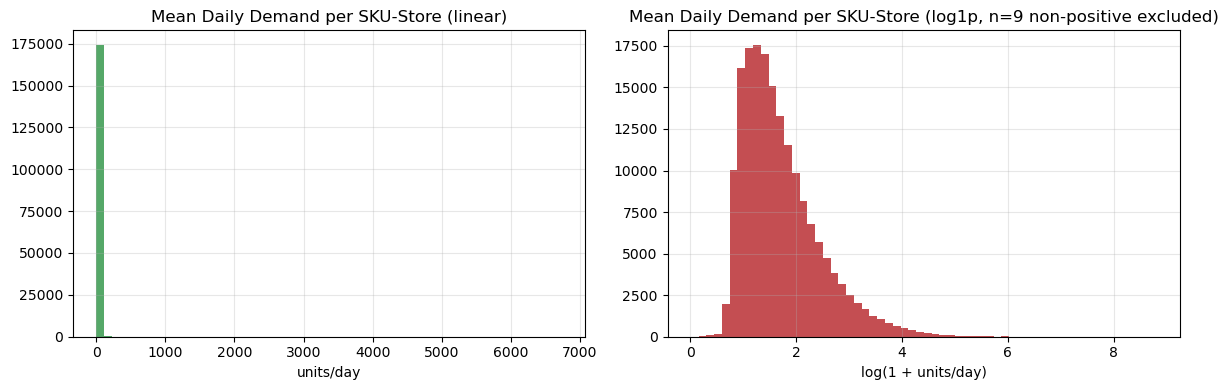

count   174,685.00
mean          7.11
std          21.86
min          -1.00
25%           2.21
50%           3.68
75%           6.98
max       6,743.81
Name: mean_daily, dtype: float64

In [4]:
demand_summary = pd.read_csv(CLEANED / "demand_summary.csv")

# daily_demand (and therefore demand_summary) is intentionally unfiltered —
# it retains zero/negative unit_sales (returns, no-sale days) so the LLM
# agent can query the complete raw history. A handful of SKUs (9 of
# 174,685 here) are returns-dominant enough to have mean_daily <= 0, which
# breaks log1p (log(1+x) is -inf for x <= -1). We exclude those from the
# log-scale panel only — the linear panel and describe() still show them.
positive_mean = demand_summary[demand_summary["mean_daily"] > 0]
n_excluded = len(demand_summary) - len(positive_mean)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(demand_summary["mean_daily"], bins=60, color="#55A868")
axes[0].set_title("Mean Daily Demand per SKU-Store (linear)")
axes[0].set_xlabel("units/day")

axes[1].hist(np.log1p(positive_mean["mean_daily"]), bins=60, color="#C44E52")
axes[1].set_title(f"Mean Daily Demand per SKU-Store (log1p, n={n_excluded} non-positive excluded)")
axes[1].set_xlabel("log(1 + units/day)")

plt.tight_layout()
plt.show()

demand_summary["mean_daily"].describe()

## Aggregate demand over time

Sum of `unit_sales` across all 581 SKU-store pairs, by date. Look for holiday spikes and any missing-date gaps.

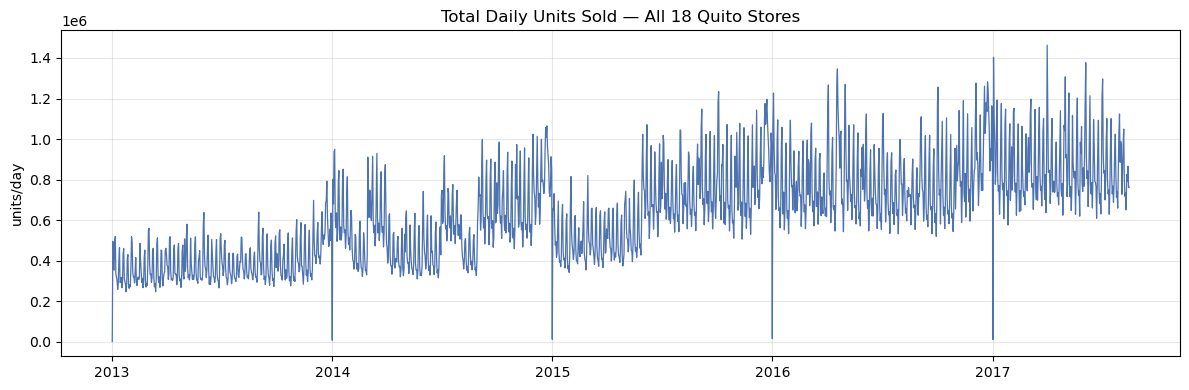

Date range: 2013-01-01 to 2017-08-15
Calendar days spanned: 1688
Distinct dates with data: 1684


In [5]:
daily_total = pd.read_sql(
    """
    SELECT date, SUM(unit_sales) AS total_units, AVG(on_promotion) AS promo_share
    FROM daily_demand
    GROUP BY date
    ORDER BY date
    """,
    conn, parse_dates=["date"],
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_total["date"], daily_total["total_units"], color="#4C72B0", linewidth=0.9)
ax.set_title("Total Daily Units Sold — All 18 Quito Stores")
ax.set_ylabel("units/day")
plt.tight_layout()
plt.show()

print(f"Date range: {daily_total['date'].min().date()} to {daily_total['date'].max().date()}")
print(f"Calendar days spanned: {(daily_total['date'].max() - daily_total['date'].min()).days + 1}")
print(f"Distinct dates with data: {len(daily_total)}")

The two sharp spikes are the year-end holiday periods (Dec 2015 and Dec 2016), consistent
with the holiday-lift finding in notebook 04 (Frozen Foods +59.8%, Liquor/Wine/Beer +36.7%
during holidays).

## Promotion frequency

6.2% of SKU-days are on promotion across 125,497,040 observations


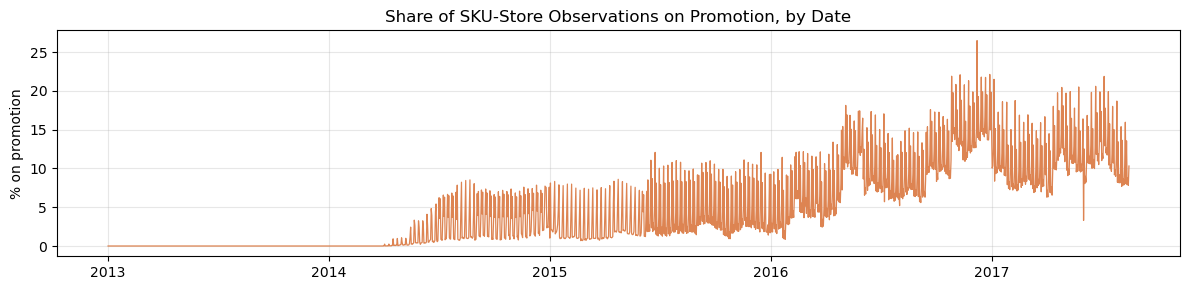

In [6]:
overall_promo_share = pd.read_sql(
    "SELECT AVG(on_promotion) AS promo_share, COUNT(*) AS n FROM daily_demand", conn
)
promo_pct = overall_promo_share.loc[0, "promo_share"] * 100
print(f"{promo_pct:.1f}% of SKU-days are on promotion across {int(overall_promo_share.loc[0, 'n']):,} observations")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(daily_total["date"], daily_total["promo_share"] * 100, color="#DD8452", linewidth=0.9)
ax.set_title("Share of SKU-Store Observations on Promotion, by Date")
ax.set_ylabel("% on promotion")
plt.tight_layout()
plt.show()

## Summary

- **Scope:** 18 Quito stores, 33 product families, 581 unique SKU-store pairs, 2015-01-02
  to 2016-12-31 (727 days, no gaps).
- **Demand is right-skewed**: a handful of GROCERY I / BEVERAGES SKUs dominate volume; most
  SKUs sell in low single digits/day. This skew is the empirical basis for ABC segmentation
  (notebook 02).
- **Clear seasonality**: total demand spikes sharply around year-end holidays in both 2015
  and 2016, motivating the promotion/holiday buffer analysis in notebook 04.
- **Promotions are common** but not universal — worth checking per-family lift rather than
  assuming a flat promo effect (done in notebook 04).

In [7]:
conn.close()